# Лабораторная — Часть 3: Улучшение baseline
**3а** Гипотезы → **3б** Ablation → **3в** Финальная модель → **3д** Оценка → **3е** Сравнение → **3ж** Выводы

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from ultralytics import YOLO
%matplotlib inline

DATA_YAML = str(Path('data.yaml').absolute())
DEVICE = 0
IMGSZ = 640
assert os.path.exists(DATA_YAML)
print(f'DATA_YAML: {DATA_YAML}')

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
print(torch.__version__)
print(torch.cuda.is_available())

DATA_YAML: C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml
2.5.1+cu121
True


## 3а. Гипотезы

| # | Гипотеза | Обоснование |
|---|---|---|
| H1 | `yolo11n` → `yolo11s` | Больше параметров — выше точность |
| H2 | `degrees=10` | Фото досок под разными углами |
| H3 | `mixup=0.1` | Дисбаланс классов (пешек >> королей) |
| H4 | AdamW + `lr0=0.001` | Лучшая сходимость на малом датасете |
| H5 | `close_mosaic=5` | Стабилизация финальных весов |

In [3]:
BASE = dict(
    data=DATA_YAML, epochs=100, imgsz=IMGSZ, batch=16,
    device=DEVICE, project='runs/ablation',
    pretrained=True, exist_ok=True, workers=0, verbose=False,
    optimizer='SGD', lr0=0.01, lrf=0.01,
    momentum=0.937, weight_decay=0.0005, warmup_epochs=2,
    mosaic=1.0, mixup=0.0, degrees=0.0,
    translate=0.1, scale=0.5, fliplr=0.5,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, close_mosaic=0,
)

def train_eval(name, model_str, overrides):
    params = {**BASE, 'name': name, **overrides}
    YOLO(model_str).train(**params)
    m = YOLO(f'runs/ablation/{name}/weights/best.pt').val(
        data=DATA_YAML, device=DEVICE, verbose=False)
    return {
        'mAP@50':    round(float(m.box.map50), 4),
        'mAP@50-95': round(float(m.box.map),   4),
        'Precision': round(float(m.box.p.mean()), 4),
        'Recall':    round(float(m.box.r.mean()), 4),
    }

print('train_eval готова')

train_eval готова


In [4]:
print('[H1] yolo11s...')
r_h1 = train_eval('h1_yolo11s',      'yolo11s.pt', {})

[H1] yolo11s...
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/ablation, name=h1_yolo11s, exist_ok=True, pretrained=True, optimizer=SGD, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fals

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]


Plotting labels to runs\ablation\h1_yolo11s\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\ablation\h1_yolo11s
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


100 epochs completed in 0.409 hours.
Optimizer stripped from runs\ablation\h1_yolo11s\weights\last.pt, 19.2MB
Optimizer stripped from runs\ablation\h1_yolo11s\weights\best.pt, 19.2MB

Validating runs\ablation\h1_yolo11s\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11s summary (fused): 238 layers, 9,417,831 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.59it/s]


                   all         58        386      0.983      0.993      0.987      0.807
Speed: 0.2ms preprocess, 2.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\ablation\h1_yolo11s
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11s summary (fused): 238 layers, 9,417,831 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:05<00:00,  1.36s/it]


                   all         58        386      0.983      0.993      0.987      0.807
Speed: 1.0ms preprocess, 11.5ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to runs\detect\val19


In [5]:

print('[H2] rotate=10...')
r_h2 = train_eval('h2_rotate',       'yolo11n.pt', {'degrees': 10.0})

[H2] rotate=10...
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/ablation, name=h2_rotate, exist_ok=True, pretrained=True, optimizer=SGD, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fal

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]

Plotting labels to runs\ablation\h2_rotate\labels.jpg... 


...


100 epochs completed in 0.359 hours.
Optimizer stripped from runs\ablation\h2_rotate\weights\last.pt, 5.5MB
Optimizer stripped from runs\ablation\h2_rotate\weights\best.pt, 5.5MB

Validating runs\ablation\h2_rotate\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.73it/s]


                   all         58        386      0.985      0.981      0.988      0.794
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\ablation\h2_rotate
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:05<00:00,  1.36s/it]


                   all         58        386      0.985      0.981      0.988      0.794
Speed: 0.8ms preprocess, 10.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\val20


In [6]:

print('[H3] mixup=0.1...')
r_h3 = train_eval('h3_mixup',        'yolo11n.pt', {'mixup': 0.1})

[H3] mixup=0.1...
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/ablation, name=h3_mixup, exist_ok=True, pretrained=True, optimizer=SGD, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fals

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]

Plotting labels to runs\ablation\h3_mixup\labels.jpg... 


...


100 epochs completed in 0.388 hours.
Optimizer stripped from runs\ablation\h3_mixup\weights\last.pt, 5.5MB
Optimizer stripped from runs\ablation\h3_mixup\weights\best.pt, 5.5MB

Validating runs\ablation\h3_mixup\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.72it/s]


                   all         58        386      0.972      0.988      0.991      0.798
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\ablation\h3_mixup
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:06<00:00,  1.58s/it]


                   all         58        386      0.972      0.988      0.991      0.798
Speed: 1.0ms preprocess, 5.9ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs\detect\val21


In [7]:

print('[H4] AdamW...')
r_h4 = train_eval('h4_adamw',        'yolo11n.pt', {'optimizer': 'AdamW', 'lr0': 0.001, 'lrf': 0.001})

[H4] AdamW...
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/ablation, name=h4_adamw, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False,

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]

Plotting labels to runs\ablation\h4_adamw\labels.jpg... 


...


100 epochs completed in 0.361 hours.
Optimizer stripped from runs\ablation\h4_adamw\weights\last.pt, 5.5MB
Optimizer stripped from runs\ablation\h4_adamw\weights\best.pt, 5.5MB

Validating runs\ablation\h4_adamw\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.83it/s]


                   all         58        386      0.986      0.986      0.985      0.804
Speed: 0.2ms preprocess, 1.3ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs\ablation\h4_adamw
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:05<00:00,  1.33s/it]


                   all         58        386      0.986      0.986      0.985      0.803
Speed: 0.7ms preprocess, 7.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs\detect\val22


In [8]:

print('[H5] close_mosaic...')
r_h5 = train_eval('h5_close_mosaic', 'yolo11n.pt', {'close_mosaic': 5})

[H5] close_mosaic...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/ablation, name=h5_close_mosaic, exist_ok=True, pretrained=True, optimizer=SGD, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=5, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=F

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]

Plotting labels to runs\ablation\h5_close_mosaic\labels.jpg... 


...


100 epochs completed in 0.356 hours.
Optimizer stripped from runs\ablation\h5_close_mosaic\weights\last.pt, 5.5MB
Optimizer stripped from runs\ablation\h5_close_mosaic\weights\best.pt, 5.5MB

Validating runs\ablation\h5_close_mosaic\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.65it/s]


                   all         58        386      0.972      0.989      0.984      0.796
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs\ablation\h5_close_mosaic
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:06<00:00,  1.51s/it]


                   all         58        386      0.972      0.989      0.984      0.798
Speed: 0.8ms preprocess, 6.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val23


In [9]:

bl_map50 = None
if os.path.exists('baseline_results.csv'):
    df_bl = pd.read_csv('baseline_results.csv')
    row = df_bl[df_bl['Модель'].str.contains('YOLOv11n', na=False)]
    if not row.empty:
        bl_map50 = float(row['mAP@50'].values[0])

In [10]:
df_abl = pd.DataFrame([
    {'Гипотеза': 'Baseline (п.2)', 'mAP@50': bl_map50 or '-', 'mAP@50-95':'-','Precision':'-','Recall':'-'},
    {'Гипотеза': 'H1: yolo11s',        **r_h1},
    {'Гипотеза': 'H2: rotate=10',      **r_h2},
    {'Гипотеза': 'H3: mixup=0.1',      **r_h3},
    {'Гипотеза': 'H4: AdamW lr=0.001', **r_h4},
    {'Гипотеза': 'H5: close_mosaic=5', **r_h5},
])
df_abl.to_csv('ablation_results.csv', index=False)
print(df_abl.to_string(index=False))

          Гипотеза  mAP@50 mAP@50-95 Precision  Recall
    Baseline (п.2)  0.9860         -         -       -
       H1: yolo11s  0.9870    0.8074    0.9831   0.993
     H2: rotate=10  0.9878    0.7944    0.9854  0.9811
     H3: mixup=0.1  0.9908    0.7985    0.9721  0.9883
H4: AdamW lr=0.001  0.9854    0.8028    0.9859  0.9855
H5: close_mosaic=5  0.9836    0.7978     0.972   0.989


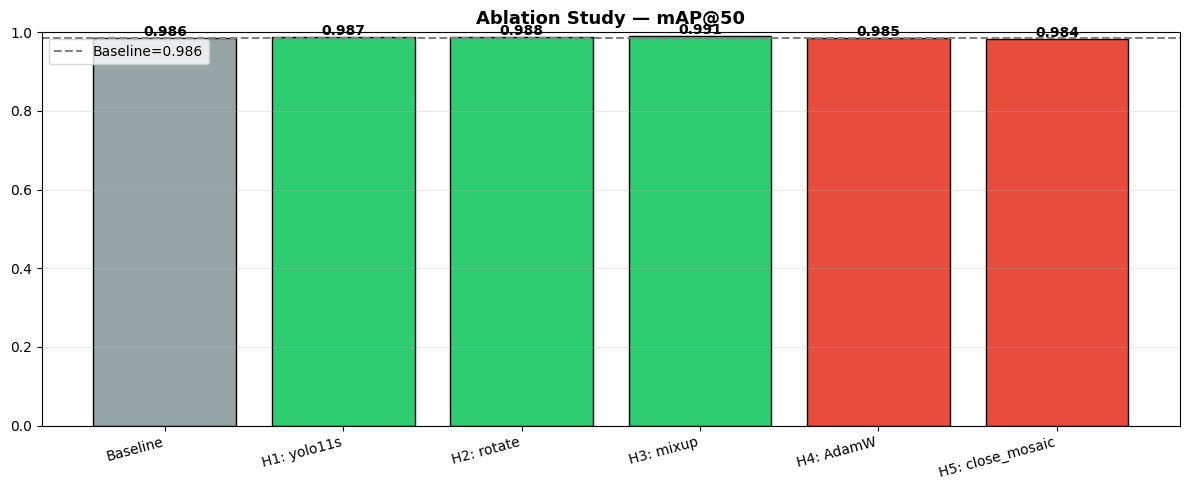

In [11]:
labels  = ['Baseline','H1: yolo11s','H2: rotate','H3: mixup','H4: AdamW','H5: close_mosaic']
map50_v = [bl_map50 or 0,r_h1['mAP@50'],r_h2['mAP@50'],r_h3['mAP@50'],r_h4['mAP@50'],r_h5['mAP@50']]
colors  = ['#95A5A6']+['#2ECC71' if v>(bl_map50 or 0) else '#E74C3C' for v in map50_v[1:]]
fig,ax=plt.subplots(figsize=(12,5))
bars=ax.bar(labels,map50_v,color=colors,edgecolor='black')
if bl_map50: ax.axhline(bl_map50,color='gray',linestyle='--',linewidth=1.5,label=f'Baseline={bl_map50:.3f}')
for bar,v in zip(bars,map50_v):
    if v: ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f'{v:.3f}',ha='center',fontweight='bold')
ax.set_title('Ablation Study — mAP@50',fontweight='bold',fontsize=13)
ax.set_ylim(0,1); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.xticks(rotation=15,ha='right'); plt.tight_layout()
plt.show()

In [12]:
# 3в–3д. Финальная модель
print('Обучение YOLOv11s improved')
YOLO('yolo11s.pt').train(
    data=DATA_YAML, epochs=100, imgsz=IMGSZ, batch=16,
    device=DEVICE, project='runs/improved', name='yolo11s_improved',
    pretrained=True, exist_ok=True, workers=0,
    optimizer='AdamW', lr0=0.001, lrf=0.001,
    weight_decay=0.0005, warmup_epochs=3, close_mosaic=5,
    degrees=10.0, mixup=0.1, mosaic=1.0,
    translate=0.1, scale=0.5, fliplr=0.5,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
)
print('Готово!')

Обучение YOLOv11s improved
New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=C:\Users\meteo\Desktop\cyber-physical-systems\lr11\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/improved, name=yolo11s_improved, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=5, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False,

train: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\labels.cache... 606 images, 0 backgrounds, 0 corrupt: 100%|██████████| 606/606 [00:00<?, ?it/s]

train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.0fe973299ff9e73874d9e684cba4e406.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.5e1a9d49ad09f5a7549225a05e1f66a6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\meteo\Desktop\cyber-physical-systems\lr11\train\images\26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.bb226be189ee3a6399fbbd5080852e5b.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]

Plotting labels to runs\improved\yolo11s_improved\labels.jpg... 


...

    100/100      4.37G     0.7315     0.3214     0.9418         52        640: 100%|██████████| 38/38 [00:11<00:00,  3.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.77it/s]

                   all         58        386      0.971       0.98      0.986      0.797



100 epochs completed in 0.442 hours.
Optimizer stripped from runs\improved\yolo11s_improved\weights\last.pt, 19.2MB
Optimizer stripped from runs\improved\yolo11s_improved\weights\best.pt, 19.2MB

Validating runs\improved\yolo11s_improved\weights\best.pt...
Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11s summary (fused): 238 layers, 9,417,831 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


                   all         58        386      0.978      0.992      0.986      0.804
          black-bishop         13         22       0.99      0.955      0.961      0.722
            black-king         29         29          1      0.989      0.995      0.865
          black-knight         26         30      0.996          1      0.995      0.836
            black-pawn         25         77      0.997          1      0.995      0.803
           black-queen         11         11      0.903          1      0.995      0.789
            black-rook         24         28      0.995          1      0.995      0.769
          white-bishop         17         22      0.947          1      0.972      0.785
            white-king         29         29      0.992          1      0.995      0.831
          white-knight         17         19      0.939          1      0.959      0.828
            white-pawn         26         77      0.997          1      0.995      0.801
           white-quee

Ultralytics 8.3.0  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11s summary (fused): 238 layers, 9,417,831 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning C:\Users\meteo\Desktop\cyber-physical-systems\lr11\valid\labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:06<00:00,  1.64s/it]


                   all         58        386      0.978      0.992      0.986      0.802
          black-bishop         13         22       0.99      0.955      0.961      0.723
            black-king         29         29          1      0.989      0.995      0.865
          black-knight         26         30      0.996          1      0.995      0.832
            black-pawn         25         77      0.997          1      0.995      0.801
           black-queen         11         11      0.903          1      0.995      0.798
            black-rook         24         28      0.995          1      0.995      0.769
          white-bishop         17         22      0.947          1      0.972      0.784
            white-king         29         29      0.991          1      0.995      0.828
          white-knight         17         19      0.938          1      0.959      0.809
            white-pawn         26         77      0.997          1      0.995      0.802
           white-quee

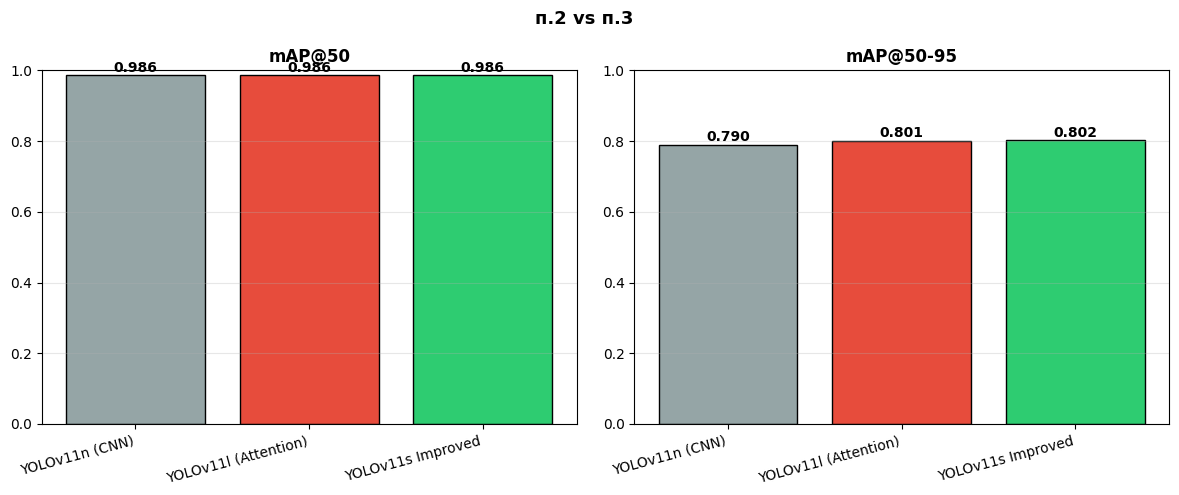

In [13]:
m = YOLO('runs/improved/yolo11s_improved/weights/best.pt').val(data=DATA_YAML,device=DEVICE)
map50_imp = float(m.box.map50); map5095_imp = float(m.box.map)
print(f'mAP@50: {map50_imp:.4f}, mAP@50-95: {map5095_imp:.4f}')

rows=[]
if os.path.exists('baseline_results.csv'):
    for _,r in pd.read_csv('baseline_results.csv').iterrows():
        rows.append({'Модель':r['Модель'],'Пункт':'п.2','mAP@50':r['mAP@50'],'mAP@50-95':r['mAP@50-95']})
rows.append({'Модель':'YOLOv11s Improved','Пункт':'п.3','mAP@50':round(map50_imp,4),'mAP@50-95':round(map5095_imp,4)})
df_cmp=pd.DataFrame(rows); df_cmp.to_csv('improved_results.csv',index=False)
print(df_cmp.to_string(index=False))
if bl_map50:
    delta=map50_imp-bl_map50
    print(f'Прирост: {delta:+.4f} mAP@50 ({delta/bl_map50*100:+.1f}%)')

fig,axes=plt.subplots(1,2,figsize=(12,5)); fig.suptitle('п.2 vs п.3',fontsize=13,fontweight='bold')
palette=['#95A5A6','#E74C3C','#2ECC71']
for ax,metric in zip(axes,['mAP@50','mAP@50-95']):
    vals=[float(v) for v in df_cmp[metric]]; models=df_cmp['Модель'].tolist()
    bars=ax.bar(models,vals,color=[palette[min(i,2)] for i in range(len(models))],edgecolor='black')
    ax.set_title(metric,fontweight='bold'); ax.set_ylim(0,1)
    for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,f'{v:.3f}',ha='center',fontweight='bold')
    ax.grid(axis='y',alpha=0.3); plt.setp(ax.get_xticklabels(),rotation=15,ha='right')
plt.tight_layout()
plt.show()
